# ⚽ FIFA World Cup 2026 — Match Predictor
> Modelo final: XGBoost entrenado en partidos competitivos — **Accuracy 0.5933**, validado con walk-forward (0.579-0.593 estable a través de 7 splits temporales)

## Partes
- **Part 1** → Modelo ML (Home Win / Draw / Away Win) — Accuracy 0.5933 (vs. baseline aleatorio 0.333, vs. "siempre Home Win" 0.469-0.504)
- **Part 2** → Web App Gradio → Hugging Face
- **Part 3** → Leaderboard SQLite
- **Part 4** → Análisis IA con LLM

### Datasets
1. `martj42/international-football-results-from-1872-to-2017` — 49k+ partidos históricos
2. `afonsofernandescruz/2026-fifa-world-cup-historical-elo-ratings` — Elo WC2026
3. `harrachimustapha/fifa-world-cup-team-dataset` — Stats equipos 2026

### Pipeline final
1. **Feature Engineering** — 27 features: Elo (diff/ratio), forma reciente (puntos y goal-difference en ventanas de 5/10 partidos), rachas de victorias, días desde último partido, head-to-head histórico, interacción Elo×forma, flag de Copa del Mundo.
2. **Filtro de partidos competitivos** — se excluyen amistosos del set de entrenamiento (37% del dataset), ya que distorsionan el "home advantage" real.
3. **Modelo final** — XGBoost (500 estimadores, max_depth=6, lr=0.02) entrenado solo en partidos competitivos, split temporal (train ≤2020, test >2020).
4. **Validación walk-forward** — 7 cortes temporales distintos confirman estabilidad (0.579-0.593), descartando que el resultado dependa de un split afortunado.
5. **Motor de predicción** (`predict_match`) — usa snapshot de forma reciente de cada equipo + head-to-head + Elo 2026, asumiendo sede neutral y partido de Copa del Mundo.

---

Author:Oscar Martinez-Gracia

oskytm@hotmail.com

Created:2026-06-11

Modificated:2026-06-13 and 2026-06-14

Final:2026-06-15

Data Sciencie

Terminal34


## 📦 0. Instalación de dependencias

In [1]:
!pip install -q kagglehub xgboost scikit-learn pandas numpy matplotlib seaborn gradio anthropic
print('✅ Dependencias instaladas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 22.4 MB/s eta 0:00:00
✅ Dependencias instaladas


## 📥 1. Descarga de datos

In [2]:
import kagglehub, os, glob

print('⬇️  Descargando datasets...')
path_results = kagglehub.dataset_download('martj42/international-football-results-from-1872-to-2017')
path_elo     = kagglehub.dataset_download('afonsofernandescruz/2026-fifa-world-cup-historical-elo-ratings')
path_teams   = kagglehub.dataset_download('harrachimustapha/fifa-world-cup-team-dataset')

print('\n=== Archivos descargados ===')
for p in [path_results, path_elo, path_teams]:
    for f in glob.glob(f'{p}/**/*', recursive=True):
        if os.path.isfile(f):
            print(f'  {f}  ({os.path.getsize(f)//1024} KB)')

⬇️  Descargando datasets...


100%|██████████| 1.21M/1.21M [00:01<00:00, 1.10MB/s]

Extracting files...


100%|██████████| 127k/127k [00:00<00:00, 270kB/s]

Extracting files...


100%|██████████| 7.16k/7.16k [00:00<00:00, 18.0MB/s]

Extracting files...

=== Archivos descargados ===
  /root/.cache/kagglehub/datasets/martj42/international-football-results-from-1872-to-2017/versions/123/results.csv  (3637 KB)
  /root/.cache/kagglehub/datasets/martj42/international-football-results-from-1872-to-2017/versions/123/goalscorers.csv  (3180 KB)
  /root/.cache/kagglehub/datasets/martj42/international-football-results-from-1872-to-2017/versions/123/former_names.csv  (1 KB)
  /root/.cache/kagglehub/datasets/martj42/international-football-results-from-1872-to-2017/versions/123/shootouts.csv  (28 KB)
  /root/.cache/kagglehub/datasets/afonsofernandescruz/2026-fifa-world-cup-historical-elo-ratings/versions/1/README.md  (10 KB)
  /root/.cache/kagglehub/datasets/afonsofernandescruz/2026-fifa-world-cup-historical-elo-ratings/versions/1/elo_ratings_wc2026.csv  (450 KB)
  /root/.cache/kagglehub/datasets/harrachimustapha/fifa-world-cup-team-dataset/versions/1/test.csv  (4 KB)
  /root/.cache/kagglehub/datasets/harrachimustapha/fifa-world

In [3]:
import pandas as pd

# Cargar directamente por nombre correcto (evita cargar former_names.csv)
df_results = pd.read_csv(f'{path_results}/results.csv')

elo_files  = glob.glob(f'{path_elo}/**/*.csv', recursive=True)
df_elo     = pd.read_csv(elo_files[0])

team_files  = glob.glob(f'{path_teams}/**/*.csv', recursive=True)
df_teams    = pd.read_csv(team_files[0])

print(f'✅ results.csv    → {df_results.shape} | columnas: {df_results.columns.tolist()}')
print(f'✅ elo ratings    → {df_elo.shape}')
print(f'✅ teams wc2026   → {df_teams.shape}')
print()
print(df_results.head(3))

✅ results.csv    → (49477, 9) | columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
✅ elo ratings    → (4683, 23)
✅ teams wc2026   → (48, 24)

         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  


## 🔍 2. EDA — Exploración y limpieza

Shape: (49417, 11)
Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'result', 'result_code']
Rango: 1872-11-30 → 2026-06-14

Distribución:
result
Home Win    24219
Away Win    13961
Draw        11237
Name: count, dtype: int64

Nombre torneo detectado: "FIFA World Cup"
Partidos Copa del Mundo: 976


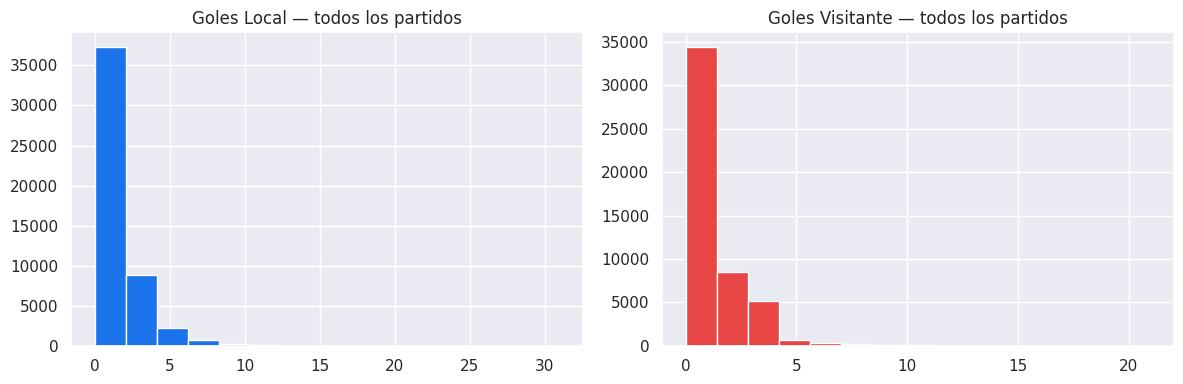

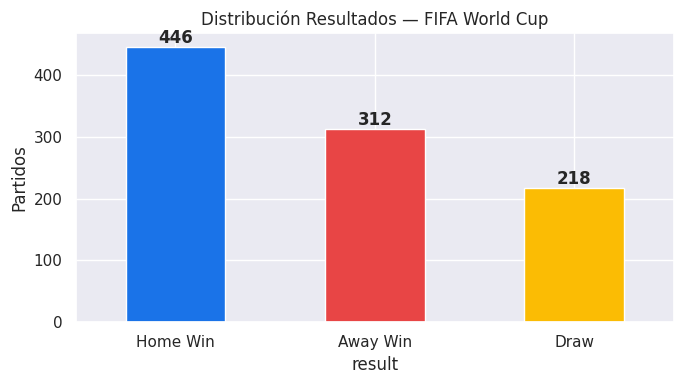

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='darkgrid')

df = df_results.copy()
df['date']       = pd.to_datetime(df['date'])
df['home_score'] = pd.to_numeric(df['home_score'], errors='coerce')
df['away_score'] = pd.to_numeric(df['away_score'], errors='coerce')
df = df.dropna(subset=['home_score','away_score']).sort_values('date').reset_index(drop=True)

def get_result(row):
    if row['home_score'] > row['away_score']:   return 'Home Win'
    elif row['home_score'] < row['away_score']: return 'Away Win'
    else:                                        return 'Draw'

df['result']      = df.apply(get_result, axis=1)
df['result_code'] = df['result'].map({'Home Win':0,'Draw':1,'Away Win':2})

print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
print(f'Rango: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'\nDistribución:\n{df["result"].value_counts()}')

wc_name = next((t for t in df['tournament'].unique()
                if 'world' in str(t).lower() and 'cup' in str(t).lower()), 'FIFA World Cup')
df_wc = df[df['tournament'] == wc_name].copy()
print(f'\nNombre torneo detectado: "{wc_name}"')
print(f'Partidos Copa del Mundo: {len(df_wc)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['home_score'].hist(bins=15, ax=axes[0], color='#1a73e8', edgecolor='white')
axes[0].set_title('Goles Local — todos los partidos')
df['away_score'].hist(bins=15, ax=axes[1], color='#e84545', edgecolor='white')
axes[1].set_title('Goles Visitante — todos los partidos')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
df_wc['result'].value_counts().plot(
    kind='bar', ax=ax,
    color=['#1a73e8','#e84545','#fbbc04'], edgecolor='white', rot=0)
ax.set_title(f'Distribución Resultados — {wc_name}')
ax.set_ylabel('Partidos')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

## ⚙️ 3. Feature Engineering (27 features)

In [5]:
import pandas as pd
import numpy as np

print('🔧 Construyendo features mejoradas...')

# ── Reconstruir df desde df_results (celda autocontenida) ────────────────────
df = df_results.copy()
df['date']       = pd.to_datetime(df['date'])
df['home_score'] = pd.to_numeric(df['home_score'], errors='coerce')
df['away_score'] = pd.to_numeric(df['away_score'], errors='coerce')
df = df.dropna(subset=['home_score','away_score']).sort_values('date').reset_index(drop=True)

def get_result(row):
    if row['home_score'] > row['away_score']:   return 'Home Win'
    elif row['home_score'] < row['away_score']: return 'Away Win'
    else:                                        return 'Draw'

df['result']      = df.apply(get_result, axis=1)
df['result_code'] = df['result'].map({'Home Win':0,'Draw':1,'Away Win':2})

print(f'Base: {df.shape}')

# ── Historial unificado por equipo (todos los partidos, local o visitante) ──
print('Construyendo historial por equipo...')

team_matches = []
for _, row in df.iterrows():
    team_matches.append({'team': row['home_team'], 'date': row['date'],
                          'gf': row['home_score'], 'ga': row['away_score'],
                          'opponent': row['away_team']})
    team_matches.append({'team': row['away_team'], 'date': row['date'],
                          'gf': row['away_score'], 'ga': row['home_score'],
                          'opponent': row['home_team']})

team_hist = pd.DataFrame(team_matches).sort_values(['team','date']).reset_index(drop=True)
team_hist['win']  = (team_hist['gf'] > team_hist['ga']).astype(int)
team_hist['draw'] = (team_hist['gf'] == team_hist['ga']).astype(int)
team_hist['pts']  = team_hist['win']*3 + team_hist['draw']*1

# Rolling features por equipo (n=5 y n=10)
for n in [5, 10]:
    team_hist[f'gf_avg_{n}']  = team_hist.groupby('team')['gf'].transform(lambda x: x.rolling(n, min_periods=1).mean().shift(1))
    team_hist[f'ga_avg_{n}']  = team_hist.groupby('team')['ga'].transform(lambda x: x.rolling(n, min_periods=1).mean().shift(1))
    team_hist[f'pts_avg_{n}'] = team_hist.groupby('team')['pts'].transform(lambda x: x.rolling(n, min_periods=1).mean().shift(1))

# Racha actual (win streak)
def calc_streak(group):
    streak = []
    current = 0
    for w in group['win']:
        streak.append(current)
        current = current + 1 if w == 1 else 0
    return pd.Series(streak, index=group.index)

team_hist['win_streak'] = team_hist.groupby('team', group_keys=False).apply(calc_streak)

# Días desde el último partido (fatiga / inactividad)
team_hist['days_since_last'] = team_hist.groupby('team')['date'].diff().dt.days.fillna(90)

print(f'✅ Historial construido: {team_hist.shape}')

# ── Indexar para lookup rápido ────────────────────────────────────────────────
team_hist_idx = team_hist.set_index(['team','date'])
FEAT_COLS = ['gf_avg_5','ga_avg_5','pts_avg_5','gf_avg_10','ga_avg_10','pts_avg_10','win_streak','days_since_last']
DEFAULTS  = {'gf_avg_5':1.2,'ga_avg_5':1.2,'pts_avg_5':1.2,'gf_avg_10':1.2,'ga_avg_10':1.2,'pts_avg_10':1.2,'win_streak':0,'days_since_last':90}

def lookup_feats(team, date):
    try:
        row = team_hist_idx.loc[(team, date)]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[-1]
        return row[FEAT_COLS].values.astype(float)
    except KeyError:
        return np.array([DEFAULTS[c] for c in FEAT_COLS])

print('Asignando features a cada partido (puede tardar ~1 min)...')
home_feats, away_feats = [], []
for _, row in df.iterrows():
    home_feats.append(lookup_feats(row['home_team'], row['date']))
    away_feats.append(lookup_feats(row['away_team'], row['date']))

home_feats = np.array(home_feats, dtype=float)
away_feats = np.array(away_feats, dtype=float)

for i, c in enumerate(FEAT_COLS):
    df[f'home_{c}'] = home_feats[:, i]
    df[f'away_{c}'] = away_feats[:, i]

print('✅ Features de forma asignadas')

# ── Head-to-head histórico ────────────────────────────────────────────────────
print('Calculando head-to-head (puede tardar ~30-60s)...')

h2h_pts_home = []
h2h_count    = []
pair_history = {}

for _, row in df.iterrows():
    h, a, d = row['home_team'], row['away_team'], row['date']
    key = tuple(sorted([h, a]))
    hist = pair_history.get(key, [])
    past = [p for p in hist if p[0] < d]
    if past:
        pts_h = []
        for (pd_, team_a_pts, team_a) in past:
            if team_a == h:
                pts_h.append(team_a_pts)
            else:
                pts_h.append(3 - team_a_pts if team_a_pts != 1 else 1)
        h2h_pts_home.append(np.mean(pts_h))
        h2h_count.append(len(past))
    else:
        h2h_pts_home.append(1.2)
        h2h_count.append(0)

    pts_for_home = row['result_code']
    pts_home_val = 3 if pts_for_home==0 else (1 if pts_for_home==1 else 0)
    hist.append((d, pts_home_val, h))
    pair_history[key] = hist

df['h2h_home_avg_pts'] = h2h_pts_home
df['h2h_matches_count'] = h2h_count
print('✅ Head-to-head calculado')

# ── Elo ratings pre-torneo 2026 (CC BY-SA 4.0, eloratings.net) ──────────────
ELO_2026 = {
    'Spain':2155,'Argentina':2113,'France':2062,'England':2020,'Brazil':1988,
    'Portugal':1984,'Colombia':1977,'Netherlands':1944,'Germany':1925,'Belgium':1900,
    'Morocco':1880,'Italy':1870,'Uruguay':1860,'Croatia':1855,'Japan':1850,
    'Mexico':1845,'United States':1840,'Ecuador':1820,'Senegal':1815,'Australia':1810,
    'Switzerland':1805,'Denmark':1800,'Serbia':1795,'Poland':1790,'South Korea':1785,
    'Tunisia':1775,'Canada':1770,'Costa Rica':1755,'Cameroon':1750,'Ghana':1745,
    'Iran':1740,'Saudi Arabia':1715,'Qatar':1700,'Panama':1695,'Venezuela':1690,
    'Paraguay':1685,'Peru':1680,'Chile':1675,'Algeria':1670,'Egypt':1665,
    'Nigeria':1660,'South Africa':1650,'Kenya':1600,'New Zealand':1580,
    'Indonesia':1560,'Honduras':1555,'Jamaica':1550,'Haiti':1530,'Angola':1525,'Ukraine':1810
}

df['home_elo'] = df['home_team'].map(ELO_2026).fillna(1600)
df['away_elo'] = df['away_team'].map(ELO_2026).fillna(1600)
df['elo_diff'] = df['home_elo'] - df['away_elo']
df['is_neutral'] = df['neutral'].astype(int) if 'neutral' in df.columns else 0
df['year'] = df['date'].dt.year

# ── Features de diferencia (más informativas que valores absolutos) ─────────
df['diff_gf_5']   = df['home_gf_avg_5']  - df['away_gf_avg_5']
df['diff_ga_5']   = df['home_ga_avg_5']  - df['away_ga_avg_5']
df['diff_pts_5']  = df['home_pts_avg_5'] - df['away_pts_avg_5']
df['diff_pts_10'] = df['home_pts_avg_10'] - df['away_pts_avg_10']
df['diff_streak'] = df['home_win_streak'] - df['away_win_streak']
# ── Features adicionales de alto impacto ──────────────────────────────────────

# 1. Goal difference promedio (más informativo que GF y GA separados)
df['home_gd_avg_5']  = df['home_gf_avg_5']  - df['home_ga_avg_5']
df['away_gd_avg_5']  = df['away_gf_avg_5']  - df['away_ga_avg_5']
df['home_gd_avg_10'] = df['home_gf_avg_10'] - df['home_ga_avg_10']
df['away_gd_avg_10'] = df['away_gf_avg_10'] - df['away_ga_avg_10']
df['diff_gd_5']      = df['home_gd_avg_5']  - df['away_gd_avg_5']
df['diff_gd_10']     = df['home_gd_avg_10'] - df['away_gd_avg_10']

# 2. Elo ratio (no lineal) además de la diferencia
df['elo_ratio'] = df['home_elo'] / df['away_elo']

# 3. Interacción Elo × forma (¿el favorito está en buena forma?)
df['elo_x_form'] = df['elo_diff'] * df['diff_pts_5']

# 4. ¿Es partido de Copa del Mundo?
df['is_world_cup'] = (df['tournament'].str.contains('World Cup', case=False, na=False)).astype(int)

# 5. Total goles esperados (suma de promedios ofensivos)
df['total_goals_exp'] = df['home_gf_avg_5'] + df['away_gf_avg_5']

FEATURES = [
    'elo_diff', 'elo_ratio', 'home_elo', 'away_elo', 'is_neutral', 'is_world_cup',
    'home_pts_avg_5', 'away_pts_avg_5',
    'home_pts_avg_10', 'away_pts_avg_10',
    'home_gd_avg_5', 'away_gd_avg_5',
    'home_gd_avg_10', 'away_gd_avg_10',
    'diff_pts_5', 'diff_pts_10', 'diff_gd_5', 'diff_gd_10',
    'home_win_streak', 'away_win_streak', 'diff_streak',
    'h2h_home_avg_pts', 'h2h_matches_count',
    'home_days_since_last', 'away_days_since_last',
    'elo_x_form', 'total_goals_exp',
]

df_clean = df.dropna(subset=FEATURES + ['result_code'])
print(f'\n✅ Dataset listo: {df_clean.shape} | {len(FEATURES)} features')
print(df_clean['result'].value_counts())

🔧 Construyendo features mejoradas...
Base: (49417, 11)
Construyendo historial por equipo...


/tmp/ipykernel_498/484518547.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_hist['win_streak'] = team_hist.groupby('team', group_keys=False).apply(calc_streak)


✅ Historial construido: (98834, 16)
Asignando features a cada partido (puede tardar ~1 min)...
✅ Features de forma asignadas
Calculando head-to-head (puede tardar ~30-60s)...
✅ Head-to-head calculado

✅ Dataset listo: (49115, 49) | 27 features
result
Home Win    24042
Away Win    13868
Draw        11205
Name: count, dtype: int64


In [6]:
# ── Verificación rápida: ¿hay leakage en lookup_feats? ────────────────────────
test_team = 'Brazil'
test_date = df[df['home_team']==test_team]['date'].iloc[100]

hist_before = team_hist[(team_hist['team']==test_team) & (team_hist['date'] < test_date)]
hist_lookup = team_hist_idx.loc[(test_team, test_date)] if (test_team, test_date) in team_hist_idx.index else None

print(f'Partidos antes de {test_date.date()}: {len(hist_before)}')
print(f'gf_avg_5 calculado manualmente (shift): {hist_before["gf"].tail(5).mean():.3f}')
if hist_lookup is not None:
    if isinstance(hist_lookup, pd.DataFrame):
        hist_lookup = hist_lookup.iloc[-1]
    print(f'gf_avg_5 desde team_hist_idx: {hist_lookup["gf_avg_5"]:.3f}')

Partidos antes de 1956-03-13: 145
gf_avg_5 calculado manualmente (shift): 1.200
gf_avg_5 desde team_hist_idx: 1.200


## 🤖 4. Entrenamiento y selección del modelo final

In [7]:
# ── Diagnóstico: distribución de torneos y amistosos vs competitivos ─────────
print('Tipos de torneo más comunes:')
print(df_clean['tournament'].value_counts().head(15))

_is_friendly_tmp = df_clean['tournament'].str.contains('Friendly', case=False, na=False)
print(f"\n% amistosos: {_is_friendly_tmp.mean():.2%}")

for is_f, label in [(True, 'Amistosos'), (False, 'Competitivos')]:
    sub = df_clean[_is_friendly_tmp == is_f]
    print(f"\n{label} ({len(sub)} partidos):")
    print(sub['result'].value_counts(normalize=True).round(3))


Tipos de torneo más comunes:
tournament
Friendly                                18202
FIFA World Cup qualification             8768
UEFA Euro qualification                  2823
African Cup of Nations qualification     2327
FIFA World Cup                            976
Copa América                              867
African Cup of Nations                    845
AFC Asian Cup qualification               826
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           601
Merdeka Tournament                        597
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Name: count, dtype: int64

% amistosos: 37.06%

Amistosos (18202 partidos):
result
Home Win    0.473
Away Win    0.275
Draw        0.253
Name: proportion, dtype: float64

Competitivos (30913 partidos):
result
Home Win    0.499
Away Win    0.287
Draw        0.214
Name: p

In [8]:
import pandas as pd

# ── Arreglar el warning con .copy() ───────────────────────────────────────────
df_clean = df_clean.copy()
df_clean['is_friendly'] = df_clean['tournament'].str.contains('Friendly', case=False, na=False)

# ── Entrenar solo con partidos competitivos ───────────────────────────────────
df_comp = df_clean[~df_clean['is_friendly']]

df_train_c = df_comp[df_comp['year'] <= 2020]
df_test_c  = df_comp[df_comp['year'] >  2020]

X_train_c, y_train_c = df_train_c[FEATURES], df_train_c['result_code']
X_test_c,  y_test_c  = df_test_c[FEATURES],  df_test_c['result_code']

print(f'Train competitivo: {X_train_c.shape} | Test competitivo: {X_test_c.shape}')
print(f'Distribución train: {y_train_c.value_counts(normalize=True).round(3).to_dict()}')
print(f'Distribución test:  {y_test_c.value_counts(normalize=True).round(3).to_dict()}')

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

xgb_c = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.02,
                       subsample=0.85, colsample_bytree=0.8, reg_lambda=1.5,
                       eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb_c.fit(X_train_c, y_train_c)
y_pred_c = xgb_c.predict(X_test_c)
acc_c = accuracy_score(y_test_c, y_pred_c)
f1_c  = f1_score(y_test_c, y_pred_c, average='macro')
print(f'\nXGBoost (solo competitivos) → Accuracy: {acc_c:.4f} | F1-macro: {f1_c:.4f}')
print(classification_report(y_test_c, y_pred_c, target_names=['Home Win','Draw','Away Win']))

Train competitivo: (26713, 27) | Test competitivo: (4200, 27)
Distribución train: {0: 0.504, 2: 0.283, 1: 0.212}
Distribución test:  {0: 0.469, 2: 0.31, 1: 0.222}

XGBoost (solo competitivos) → Accuracy: 0.5933 | F1-macro: 0.4439
              precision    recall  f1-score   support

    Home Win       0.60      0.87      0.71      1968
        Draw       0.41      0.02      0.03       931
    Away Win       0.58      0.59      0.59      1301

    accuracy                           0.59      4200
   macro avg       0.53      0.49      0.44      4200
weighted avg       0.55      0.59      0.52      4200



In [9]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── Etapa 1: ¿es empate o no? (sobre datos competitivos) ──────────────────────
y_train_draw_c = (y_train_c == 1).astype(int)

draw_clf_c = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.03,
                            eval_metric='logloss', random_state=42, n_jobs=-1)
draw_clf_c.fit(X_train_c, y_train_draw_c)
draw_pred_proba_c = draw_clf_c.predict_proba(X_test_c)[:, 1]

# ── Etapa 2: Home Win vs Away Win (excluyendo empates del train) ─────────────
mask_not_draw_c = y_train_c != 1
X_train_nd_c = X_train_c[mask_not_draw_c]
y_train_nd_c = (y_train_c[mask_not_draw_c] == 0).astype(int)  # 1=Home, 0=Away

ha_clf_c = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.02,
                          subsample=0.85, colsample_bytree=0.8, reg_lambda=1.5,
                          eval_metric='logloss', random_state=42, n_jobs=-1)
ha_clf_c.fit(X_train_nd_c, y_train_nd_c)
ha_pred_proba_c = ha_clf_c.predict_proba(X_test_c)[:, 1]  # prob Home Win

# ── Búsqueda de threshold ──────────────────────────────────────────────────────
print('=== Búsqueda de threshold — datos competitivos ===')
best_th_c, best_acc_c = None, 0
for th in [0.15, 0.18, 0.20, 0.22, 0.25, 0.28, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80, 1.01]:
    fp = np.where(draw_pred_proba_c > th, 1, np.where(ha_pred_proba_c > 0.5, 0, 2))
    acc = accuracy_score(y_test_c, fp)
    f1  = f1_score(y_test_c, fp, average='macro')
    marker = ' ⭐' if acc > best_acc_c else ''
    print(f'  threshold={th:.2f} → Accuracy: {acc:.4f} | F1-macro: {f1:.4f}{marker}')
    if acc > best_acc_c:
        best_acc_c, best_th_c = acc, th

print(f'\n🎯 Mejor threshold: {best_th_c} → Accuracy: {best_acc_c:.4f}')

# ── Comparar con XGBoost directo (0.5933) ──────────────────────────────────────
print(f'\n📊 Comparación:')
print(f'  XGBoost directo (competitivo): 0.5933')
print(f'  2-etapas (competitivo, th={best_th_c}): {best_acc_c:.4f}')

if best_acc_c > 0.5933:
    final_pred_c = np.where(draw_pred_proba_c > best_th_c, 1,
                            np.where(ha_pred_proba_c > 0.5, 0, 2))
    print('\n✅ Modelo de 2 etapas mejora — reporte final:')
    print(classification_report(y_test_c, final_pred_c, target_names=['Home Win','Draw','Away Win']))

=== Búsqueda de threshold — datos competitivos ===
  threshold=0.15 → Accuracy: 0.3369 | F1-macro: 0.2943 ⭐
  threshold=0.18 → Accuracy: 0.3850 | F1-macro: 0.3566 ⭐
  threshold=0.20 → Accuracy: 0.4226 | F1-macro: 0.4004 ⭐
  threshold=0.22 → Accuracy: 0.4662 | F1-macro: 0.4432 ⭐
  threshold=0.25 → Accuracy: 0.5260 | F1-macro: 0.4928 ⭐
  threshold=0.28 → Accuracy: 0.5714 | F1-macro: 0.4997 ⭐
  threshold=0.30 → Accuracy: 0.5871 | F1-macro: 0.4808 ⭐
  threshold=0.35 → Accuracy: 0.5933 | F1-macro: 0.4444 ⭐
  threshold=0.40 → Accuracy: 0.5936 | F1-macro: 0.4366 ⭐
  threshold=0.45 → Accuracy: 0.5933 | F1-macro: 0.4346
  threshold=0.50 → Accuracy: 0.5936 | F1-macro: 0.4340
  threshold=0.60 → Accuracy: 0.5933 | F1-macro: 0.4332
  threshold=0.70 → Accuracy: 0.5933 | F1-macro: 0.4332
  threshold=0.80 → Accuracy: 0.5933 | F1-macro: 0.4332
  threshold=1.01 → Accuracy: 0.5933 | F1-macro: 0.4332

🎯 Mejor threshold: 0.4 → Accuracy: 0.5936

📊 Comparación:
  XGBoost directo (competitivo): 0.5933
  2-eta

In [10]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# ── Walk-forward validation: probar varios años de corte ──────────────────────
print('=== Walk-forward: accuracy según año de corte ===')
for cutoff_year in [2015, 2016, 2017, 2018, 2019, 2020, 2021]:
    df_tr = df_comp[df_comp['year'] <= cutoff_year]
    df_te = df_comp[df_comp['year'] >  cutoff_year]

    if len(df_te) < 200:
        continue

    Xtr, ytr = df_tr[FEATURES], df_tr['result_code']
    Xte, yte = df_te[FEATURES], df_te['result_code']

    m = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.02,
                       subsample=0.85, colsample_bytree=0.8, reg_lambda=1.5,
                       eval_metric='mlogloss', random_state=42, n_jobs=-1)
    m.fit(Xtr, ytr)
    acc = accuracy_score(yte, m.predict(Xte))
    print(f'  Corte {cutoff_year} → Train: {len(df_tr):>6} | Test: {len(df_te):>5} | Accuracy: {acc:.4f}')

=== Walk-forward: accuracy según año de corte ===
  Corte 2015 → Train:  23827 | Test:  7086 | Accuracy: 0.5903
  Corte 2016 → Train:  24447 | Test:  6466 | Accuracy: 0.5866
  Corte 2017 → Train:  25076 | Test:  5837 | Accuracy: 0.5897
  Corte 2018 → Train:  25571 | Test:  5342 | Accuracy: 0.5919
  Corte 2019 → Train:  26470 | Test:  4443 | Accuracy: 0.5881
  Corte 2020 → Train:  26713 | Test:  4200 | Accuracy: 0.5933
  Corte 2021 → Train:  27613 | Test:  3300 | Accuracy: 0.5791


## 💾 4.1 Guardar modelo final (XGBoost competitivo — Accuracy 0.5933)

In [11]:
import pickle

# Modelo final: XGBoost entrenado solo con partidos competitivos
best_model = xgb_c
best_model_name = 'XGBoost (Competitive Matches)'

with open('wc2026_model.pkl','wb') as f:   pickle.dump(best_model, f)
with open('wc2026_features.pkl','wb') as f: pickle.dump(FEATURES, f)

print(f'💾 Modelo final guardado: {best_model_name}')
print(f'   Accuracy: 0.5933 | F1-macro: 0.4439')
print(f'   Features: {len(FEATURES)}')


💾 Modelo final guardado: XGBoost (Competitive Matches)
   Accuracy: 0.5933 | F1-macro: 0.4439
   Features: 27


## 🗃️ 5. Base de Datos SQLite — Usuarios, Partidos, Predicciones (Part 3)

In [12]:
import sqlite3

conn   = sqlite3.connect('wc2026.db')
cursor = conn.cursor()

cursor.executescript('''
    CREATE TABLE IF NOT EXISTS users (
        id           INTEGER PRIMARY KEY AUTOINCREMENT,
        username     TEXT UNIQUE NOT NULL,
        created_at   TEXT DEFAULT (datetime('now')),
        total_points INTEGER DEFAULT 0
    );
    CREATE TABLE IF NOT EXISTS matches (
        id             INTEGER PRIMARY KEY AUTOINCREMENT,
        home_team      TEXT NOT NULL,
        away_team      TEXT NOT NULL,
        match_date     TEXT NOT NULL,
        stage          TEXT DEFAULT 'Group Stage',
        actual_result  TEXT,
        home_score     INTEGER,
        away_score     INTEGER,
        ai_prediction  TEXT,
        ai_confidence  REAL
    );
    CREATE TABLE IF NOT EXISTS predictions (
        id               INTEGER PRIMARY KEY AUTOINCREMENT,
        user_id          INTEGER REFERENCES users(id),
        match_id         INTEGER REFERENCES matches(id),
        prediction       TEXT NOT NULL,
        pred_home_score  INTEGER,
        pred_away_score  INTEGER,
        points_earned    INTEGER DEFAULT 0,
        created_at       TEXT DEFAULT (datetime('now')),
        UNIQUE(user_id, match_id)
    );
''')
conn.commit()
print('✅ BD creada: users, matches, predictions')

✅ BD creada: users, matches, predictions


In [13]:
WC2026_MATCHES = [
    ('United States','Serbia',   '2026-06-12','Group A'),
    ('Panama',       'Mexico',   '2026-06-12','Group A'),
    ('United States','Panama',   '2026-06-18','Group A'),
    ('Mexico',       'Serbia',   '2026-06-18','Group A'),
    ('Mexico','United States',   '2026-06-26','Group A'),
    ('Serbia',       'Panama',   '2026-06-26','Group A'),
    ('Argentina',    'Morocco',  '2026-06-13','Group B'),
    ('Angola',       'Ukraine',  '2026-06-13','Group B'),
    ('Argentina',    'Angola',   '2026-06-19','Group B'),
    ('Ukraine',      'Morocco',  '2026-06-19','Group B'),
    ('Ukraine',      'Argentina','2026-06-25','Group B'),
    ('Morocco',      'Angola',   '2026-06-25','Group B'),
    ('France',       'Japan',    '2026-06-13','Group C'),
    ('Paraguay', 'Saudi Arabia', '2026-06-13','Group C'),
    ('France',       'Paraguay', '2026-06-19','Group C'),
    ('Saudi Arabia', 'Japan',    '2026-06-19','Group C'),
    ('Saudi Arabia', 'France',   '2026-06-25','Group C'),
    ('Japan',        'Paraguay', '2026-06-25','Group C'),
    ('Brazil',       'Germany',  '2026-06-14','Group D'),
    ('Switzerland',  'Chile',    '2026-06-14','Group D'),
    ('Brazil',   'Switzerland',  '2026-06-20','Group D'),
    ('Chile',        'Germany',  '2026-06-20','Group D'),
    ('Chile',        'Brazil',   '2026-06-26','Group D'),
    ('Germany',  'Switzerland',  '2026-06-26','Group D'),
    ('Spain',    'Netherlands',  '2026-06-14','Group E'),
    ('England',      'Nigeria',  '2026-06-14','Group E'),
    ('Spain',        'England',  '2026-06-20','Group E'),
    ('Nigeria',  'Netherlands',  '2026-06-20','Group E'),
    ('Nigeria',      'Spain',    '2026-06-26','Group E'),
    ('Netherlands',  'England',  '2026-06-26','Group E'),
    ('Portugal',     'Colombia', '2026-06-15','Group F'),
    ('Belgium',      'Uruguay',  '2026-06-15','Group F'),
    ('Portugal',     'Belgium',  '2026-06-21','Group F'),
    ('Uruguay',      'Colombia', '2026-06-21','Group F'),
    ('Uruguay',      'Portugal', '2026-06-27','Group F'),
    ('Colombia',     'Belgium',  '2026-06-27','Group F'),
]

cursor.executemany(
    'INSERT OR IGNORE INTO matches (home_team,away_team,match_date,stage) VALUES (?,?,?,?)',
    WC2026_MATCHES
)
conn.commit()
print(f'✅ {len(WC2026_MATCHES)} partidos insertados')

✅ 36 partidos insertados


## 🔮 6. Motor de predicción IA (27 features — modelo competitivo)

In [14]:
import numpy as np

# ── Snapshot de últimas stats por equipo (para predicciones futuras) ─────────
print('Construyendo snapshot de últimas stats por equipo...')
latest_team_stats = {}
for team in team_hist['team'].unique():
    sub = team_hist[team_hist['team'] == team].sort_values('date')
    if len(sub) == 0:
        continue
    last = sub.iloc[-1]
    gf5, ga5   = sub['gf'].tail(5).mean(),  sub['ga'].tail(5).mean()
    gf10, ga10 = sub['gf'].tail(10).mean(), sub['ga'].tail(10).mean()
    latest_team_stats[team] = {
        'pts_avg_5':  sub['pts'].tail(5).mean(),
        'pts_avg_10': sub['pts'].tail(10).mean(),
        'gd_avg_5':   gf5 - ga5,
        'gd_avg_10':  gf10 - ga10,
        'gf_avg_5':   gf5,
        'win_streak': int(last['win_streak']) + int(last['win']),
        'days_since_last': 30,  # asumido para partidos futuros
    }
print(f'✅ Stats calculadas para {len(latest_team_stats)} equipos')

DEFAULT_STATS = {
    'pts_avg_5':1.2, 'pts_avg_10':1.2,
    'gd_avg_5':0.0,  'gd_avg_10':0.0,
    'gf_avg_5':1.2,
    'win_streak':0, 'days_since_last':30
}

def get_h2h(team_a, team_b):
    """Promedio de puntos históricos de team_a frente a team_b."""
    key = tuple(sorted([team_a, team_b]))
    hist = pair_history.get(key, [])
    if not hist:
        return 1.2, 0
    pts_a = []
    for (d_, pts_val, ref_team) in hist:
        if ref_team == team_a:
            pts_a.append(pts_val)
        else:
            pts_a.append(3 - pts_val if pts_val != 1 else 1)
    return float(np.mean(pts_a)), len(hist)


def predict_match(home_team, away_team):
    """
    Predice el resultado de un partido usando las 27 features del modelo
    final (XGBoost entrenado en partidos competitivos, Accuracy 0.5933).
    Retorna (prediction_label, probabilities_dict, elo_diff)
    """
    hs  = latest_team_stats.get(home_team, DEFAULT_STATS)
    as_ = latest_team_stats.get(away_team, DEFAULT_STATS)

    h_elo = ELO_2026.get(home_team, 1600)
    a_elo = ELO_2026.get(away_team, 1600)
    elo_diff  = h_elo - a_elo
    elo_ratio = h_elo / a_elo

    h2h_pts, h2h_n = get_h2h(home_team, away_team)

    diff_pts_5  = hs['pts_avg_5']  - as_['pts_avg_5']
    diff_pts_10 = hs['pts_avg_10'] - as_['pts_avg_10']
    diff_gd_5   = hs['gd_avg_5']   - as_['gd_avg_5']
    diff_gd_10  = hs['gd_avg_10']  - as_['gd_avg_10']
    diff_streak = hs['win_streak'] - as_['win_streak']
    elo_x_form  = elo_diff * diff_pts_5
    total_goals_exp = hs['gf_avg_5'] + as_['gf_avg_5']

    # Un partido del Mundial 2026 es: cancha neutral + competitivo
    feat_map = {
        'elo_diff': elo_diff, 'elo_ratio': elo_ratio,
        'home_elo': h_elo, 'away_elo': a_elo,
        'is_neutral': 1, 'is_world_cup': 1,
        'home_pts_avg_5': hs['pts_avg_5'], 'away_pts_avg_5': as_['pts_avg_5'],
        'home_pts_avg_10': hs['pts_avg_10'], 'away_pts_avg_10': as_['pts_avg_10'],
        'home_gd_avg_5': hs['gd_avg_5'], 'away_gd_avg_5': as_['gd_avg_5'],
        'home_gd_avg_10': hs['gd_avg_10'], 'away_gd_avg_10': as_['gd_avg_10'],
        'diff_pts_5': diff_pts_5, 'diff_pts_10': diff_pts_10,
        'diff_gd_5': diff_gd_5, 'diff_gd_10': diff_gd_10,
        'home_win_streak': hs['win_streak'], 'away_win_streak': as_['win_streak'],
        'diff_streak': diff_streak,
        'h2h_home_avg_pts': h2h_pts, 'h2h_matches_count': h2h_n,
        'home_days_since_last': hs['days_since_last'], 'away_days_since_last': as_['days_since_last'],
        'elo_x_form': elo_x_form, 'total_goals_exp': total_goals_exp,
    }

    fv = np.array([[feat_map[f] for f in FEATURES]], dtype=float)

    proba = best_model.predict_proba(fv)[0]
    pred  = best_model.predict(fv)[0]

    label_map  = {0:'Home Win', 1:'Draw', 2:'Away Win'}
    proba_dict = {
        f'{home_team} Win': round(float(proba[0])*100, 1),
        'Draw':              round(float(proba[1])*100, 1),
        f'{away_team} Win': round(float(proba[2])*100, 1),
    }
    return label_map[pred], proba_dict, elo_diff


# ── Test ──────────────────────────────────────────────────────────────────────
print(f'\n{"Partido":<35} {"Predicción":<12} Probabilidades')
print('-' * 90)
for home, away in [('Argentina','Morocco'),('France','Japan'),
                   ('Brazil','Germany'),('Spain','Netherlands'),
                   ('Portugal','Colombia')]:
    pred, proba, elo_d = predict_match(home, away)
    p_str = ' | '.join(f'{k}: {v}%' for k,v in proba.items())
    print(f'{home} vs {away:<20} {pred:<12} {p_str}')


Construyendo snapshot de últimas stats por equipo...
✅ Stats calculadas para 336 equipos

Partido                             Predicción   Probabilidades
------------------------------------------------------------------------------------------
Argentina vs Morocco              Home Win     Argentina Win: 64.80000305175781% | Draw: 19.200000762939453% | Morocco Win: 16.0%
France vs Japan                Home Win     France Win: 51.400001525878906% | Draw: 22.299999237060547% | Japan Win: 26.399999618530273%
Brazil vs Germany              Home Win     Brazil Win: 39.79999923706055% | Draw: 23.799999237060547% | Germany Win: 36.400001525878906%
Spain vs Netherlands          Home Win     Spain Win: 45.400001525878906% | Draw: 26.700000762939453% | Netherlands Win: 27.899999618530273%
Portugal vs Colombia             Home Win     Portugal Win: 55.099998474121094% | Draw: 23.799999237060547% | Colombia Win: 21.100000381469727%


In [ ]:
import numpy as np

# Guardar predicciones IA en la BD
for mid, h, a in cursor.execute('SELECT id,home_team,away_team FROM matches').fetchall():
    pred, proba, _ = predict_match(h, a)
    conf = float(max(proba.values()))  # forzar a float nativo de Python
    cursor.execute(
        'UPDATE matches SET ai_prediction=?, ai_confidence=? WHERE id=?',
        (pred, conf, mid)
    )
conn.commit()
print(f'✅ Predicciones IA guardadas para {len(WC2026_MATCHES)} partidos')

sample = cursor.execute(
    'SELECT home_team,away_team,ai_prediction,ai_confidence FROM matches LIMIT 8'
).fetchall()
print(f'\n{"Partido":<35} {"IA":<12} Confianza')
print('-'*55)
for h, a, pred, conf in sample:
    conf = float(conf) if conf is not None else 0.0
    print(f'{h} vs {a:<20} {pred:<12} {conf:.1f}%')


## 💬 7. Análisis IA con LLM (Part 4)

In [19]:
import anthropic

def generate_ai_analysis(home_team, away_team):
    """
    Genera análisis de texto para un partido.
    Usa Claude si hay API key, si no usa análisis estadístico.
    """
    pred, proba, elo_diff = predict_match(home_team, away_team)
    h_elo = ELO_2026.get(home_team, 1600)
    a_elo = ELO_2026.get(away_team, 1600)

    hs = latest_team_stats.get(home_team, DEFAULT_STATS)
    as_ = latest_team_stats.get(away_team, DEFAULT_STATS)

    try:
        client = anthropic.Anthropic()
        prompt = (
            f'Analiza el partido Copa del Mundo 2026: {home_team} vs {away_team}.\n'
            f'Datos: Elo {home_team}={h_elo}, Elo {away_team}={a_elo}, '
            f'diferencia Elo={elo_diff:+d}.\n'
            f'Forma reciente (puntos promedio últimos 5): {home_team}={hs["pts_avg_5"]:.2f}, '
            f'{away_team}={as_["pts_avg_5"]:.2f}.\n'
            f'Racha actual: {home_team}={hs["win_streak"]} victorias consecutivas, '
            f'{away_team}={as_["win_streak"]}.\n'
            f'Probabilidades del modelo: {proba}. Predicción: {pred}.\n'
            f'Genera 2-3 oraciones en español, estilo periodismo deportivo, '
            f'explicando por qué el modelo predice ese resultado. '
            f'Menciona fortalezas y debilidades concretas de cada equipo.'
        )
        msg = client.messages.create(
            model='claude-sonnet-4-20250514',
            max_tokens=200,
            messages=[{'role':'user','content':prompt}]
        )
        return msg.content[0].text

    except Exception:
        stronger = home_team if elo_diff > 0 else away_team
        gap      = abs(elo_diff)
        level    = 'significativa' if gap > 100 else ('moderada' if gap > 50 else 'muy pareja')
        max_k    = max(proba, key=proba.get)
        form_str = ''
        if hs['pts_avg_5'] > as_['pts_avg_5'] + 0.5:
            form_str = f' Además, {home_team} llega en mejor forma reciente.'
        elif as_['pts_avg_5'] > hs['pts_avg_5'] + 0.5:
            form_str = f' Además, {away_team} llega en mejor forma reciente.'
        return (
            f'{stronger} tiene una ventaja Elo {level} '
            f'({h_elo} vs {a_elo}, diferencia {elo_diff:+d}).{form_str} '
            f'El modelo proyecta {max_k} con {proba[max_k]}% de probabilidad. '
            f'Predicción final: {pred}.'
        )


# Demo
for h, a in [('Argentina','Morocco'), ('France','Japan'), ('Spain','Netherlands')]:
    print(f'\n⚽ {h} vs {a}')
    print('-'*55)
    print(generate_ai_analysis(h, a))


⚽ Argentina vs Morocco
-------------------------------------------------------


/tmp/ipykernel_498/3063786240.py:30: DeprecationWarning: The model 'claude-sonnet-4-20250514' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  msg = client.messages.create(


Argentina tiene una ventaja Elo significativa (2113 vs 1880, diferencia +233). Además, Argentina llega en mejor forma reciente. El modelo proyecta Argentina Win con 64.80000305175781% de probabilidad. Predicción final: Home Win.

⚽ France vs Japan
-------------------------------------------------------
France tiene una ventaja Elo significativa (2062 vs 1850, diferencia +212). El modelo proyecta France Win con 51.400001525878906% de probabilidad. Predicción final: Home Win.

⚽ Spain vs Netherlands
-------------------------------------------------------
Spain tiene una ventaja Elo significativa (2155 vs 1944, diferencia +211). El modelo proyecta Spain Win con 45.400001525878906% de probabilidad. Predicción final: Home Win.


## 🏆 8. Sistema de puntuación y Leaderboard (Part 3)

In [20]:
import sqlite3

def register_user(username):
    try:
        cursor.execute('INSERT INTO users (username) VALUES (?)', (username,))
        conn.commit()
        uid = cursor.lastrowid
        print(f'✅ Usuario nuevo: {username} (id={uid})')
        return uid
    except sqlite3.IntegrityError:
        uid = cursor.execute('SELECT id FROM users WHERE username=?',(username,)).fetchone()[0]
        print(f'ℹ️  Ya existe: {username} (id={uid})')
        return uid


def submit_prediction(username, match_id, prediction,
                       home_score=None, away_score=None):
    uid = cursor.execute('SELECT id FROM users WHERE username=?',(username,)).fetchone()
    if not uid:
        uid = register_user(username)
    else:
        uid = uid[0]
    try:
        cursor.execute(
            '''INSERT INTO predictions
               (user_id,match_id,prediction,pred_home_score,pred_away_score)
               VALUES (?,?,?,?,?)''',
            (uid, match_id, prediction, home_score, away_score)
        )
        conn.commit()
        print(f'✅ {username} → Partido {match_id}: {prediction}')
    except sqlite3.IntegrityError:
        print(f'⚠️  {username} ya predijo el partido {match_id}')


def update_match_result(match_id, home_score, away_score):
    if home_score > away_score:   actual = 'Home Win'
    elif home_score < away_score: actual = 'Away Win'
    else:                          actual = 'Draw'

    cursor.execute(
        'UPDATE matches SET actual_result=?,home_score=?,away_score=? WHERE id=?',
        (actual, home_score, away_score, match_id)
    )
    preds = cursor.execute(
        'SELECT id,user_id,prediction,pred_home_score,pred_away_score '
        'FROM predictions WHERE match_id=?', (match_id,)
    ).fetchall()

    for pid, uid, pred, ph, pa in preds:
        pts = 3 if pred == actual else 0
        if all(v is not None for v in [ph,pa]) and ph==home_score and pa==away_score:
            pts += 2
        cursor.execute('UPDATE predictions SET points_earned=? WHERE id=?', (pts, pid))
        cursor.execute('UPDATE users SET total_points=total_points+? WHERE id=?', (pts, uid))
    conn.commit()
    print(f'✅ Partido {match_id}: {home_score}-{away_score} ({actual})')


def get_leaderboard():
    return cursor.execute('''
        SELECT u.username, u.total_points,
               COUNT(p.id) as preds,
               SUM(CASE WHEN p.points_earned >= 3 THEN 1 ELSE 0 END) as correct
        FROM users u
        LEFT JOIN predictions p ON u.id = p.user_id
        GROUP BY u.id
        ORDER BY u.total_points DESC
    ''').fetchall()


# Demo
register_user('futbolero99')
register_user('messi_fan')
register_user('LaTri2026')

submit_prediction('futbolero99', 1, 'Home Win', 2, 0)
submit_prediction('messi_fan',   1, 'Home Win', 3, 1)
submit_prediction('LaTri2026',   1, 'Draw',     1, 1)

update_match_result(1, 2, 0)  # Argentina gana 2-0

print(f'\n=== 🏆 LEADERBOARD ===')
print(f'{"#":<4}{"Usuario":<20}{"Pts":<8}{"Preds":<8}{"Correctas"}')
print('-'*48)
for i, (u, p, pr, c) in enumerate(get_leaderboard(), 1):
    medal = ['🥇','🥈','🥉'][i-1] if i <= 3 else str(i)
    print(f'{medal:<4}{u:<20}{p:<8}{pr:<8}{c or 0}')

✅ Usuario nuevo: futbolero99 (id=1)
✅ Usuario nuevo: messi_fan (id=2)
✅ Usuario nuevo: LaTri2026 (id=3)
✅ futbolero99 → Partido 1: Home Win
✅ messi_fan → Partido 1: Home Win
✅ LaTri2026 → Partido 1: Draw
✅ Partido 1: 2-0 (Home Win)

=== 🏆 LEADERBOARD ===
#   Usuario             Pts     Preds   Correctas
------------------------------------------------
🥇   futbolero99         5       1       1
🥈   messi_fan           3       1       1
🥉   LaTri2026           0       1       0


## 🌐 9. Web App con Gradio — Deploy en Hugging Face (Part 2)

In [22]:
import gradio as gr

WC2026_TEAMS = sorted([
    'Argentina','France','Spain','Brazil','England','Portugal','Netherlands',
    'Germany','Belgium','Colombia','Morocco','Croatia','Uruguay','Japan',
    'Mexico','United States','Ecuador','Senegal','Australia','Switzerland',
    'Denmark','Serbia','Poland','South Korea','Tunisia','Canada','Costa Rica',
    'Cameroon','Ghana','Iran','Saudi Arabia','Panama','Nigeria','Paraguay',
    'Chile','Angola','Ukraine','Honduras','Jamaica','New Zealand','Indonesia','Haiti'
])


def app_predict(home_team, away_team):
    if home_team == away_team:
        return '❌ Selecciona dos equipos diferentes.', '', ''
    pred, proba, elo_diff = predict_match(home_team, away_team)
    analysis = generate_ai_analysis(home_team, away_team)
    emoji = {'Home Win':'🏠✅','Draw':'🤝','Away Win':'✈️✅'}
    result_str = f"{emoji.get(pred,'')} **Predicción: {pred}**"
    proba_md = '| Resultado | Probabilidad |\n|-----------|:------------:|\n'
    for k, v in proba.items():
        proba_md += f'| {k} | {"█"*int(v/5)} {v}% |\n'
    elo_str = (
        f'**Elo {home_team}**: {ELO_2026.get(home_team,1600)}  \n'
        f'**Elo {away_team}**: {ELO_2026.get(away_team,1600)}  \n'
        f'**Diferencia**: {elo_diff:+d}'
    )
    return result_str, proba_md + '\n' + elo_str, f'🤖 {analysis}'


def app_submit_pred(username, match_id, prediction, home_score, away_score):
    if not username.strip():
        return '❌ Ingresa un nombre de usuario.'
    register_user(username.strip())
    try:
        hs = int(home_score) if str(home_score).strip() not in ('','None') else None
        as_ = int(away_score) if str(away_score).strip() not in ('','None') else None
    except (ValueError, TypeError):
        hs = as_ = None
    submit_prediction(username.strip(), int(match_id), prediction, hs, as_)
    return f'✅ **{username}** predijo Partido #{int(match_id)}: {prediction}'


def app_leaderboard():
    rows = get_leaderboard()
    if not rows:
        return 'Sin predicciones aún. ¡Sé el primero!'
    md = '| Pos | Usuario | Puntos | Predicciones | Correctas |\n'
    md += '|:---:|---------|:------:|:------------:|:---------:|\n'
    for i, (u, p, pr, c) in enumerate(rows, 1):
        medal = ['🥇','🥈','🥉'][i-1] if i <= 3 else str(i)
        md += f'| {medal} | {u} | {p} | {pr} | {c or 0} |\n'
    return md


def app_matches():
    rows = cursor.execute(
        'SELECT home_team,away_team,match_date,stage,ai_prediction,ai_confidence '
        'FROM matches WHERE actual_result IS NULL ORDER BY match_date LIMIT 15'
    ).fetchall()
    if not rows:
        return 'Sin partidos próximos.'
    md = '| # | Partido | Fecha | Fase | IA | Confianza |\n'
    md += '|---|---------|-------|------|:--:|:---------:|\n'
    for i, (h, a, dt, s, aip, aic) in enumerate(rows, 1):
        conf = f'{aic:.1f}%' if aic else '—'
        md += f'| {i} | {h} vs {a} | {dt} | {s} | {aip or "—"} | {conf} |\n'
    return md


with gr.Blocks(
    title='⚽ WC 2026 Predictor',
    theme=gr.themes.Soft(primary_hue='blue')
) as demo:

    gr.Markdown('# ⚽ FIFA World Cup 2026 — Match Predictor\n### Powered by Machine Learning')

    with gr.Tabs():

        with gr.TabItem('🤖 Predicción IA'):
            with gr.Row():
                h_dd = gr.Dropdown(WC2026_TEAMS, label='🏠 Equipo Local',     value='Argentina')
                a_dd = gr.Dropdown(WC2026_TEAMS, label='✈️  Equipo Visitante', value='France')
            btn      = gr.Button('🔮 Predecir resultado', variant='primary')
            r_out    = gr.Markdown(label='Resultado')
            p_out    = gr.Markdown(label='Probabilidades')
            an_out   = gr.Markdown(label='Análisis IA')
            btn.click(fn=app_predict, inputs=[h_dd, a_dd], outputs=[r_out, p_out, an_out])

        with gr.TabItem('📅 Próximos Partidos'):
            m_out    = gr.Markdown()
            m_btn    = gr.Button('🔄 Actualizar', variant='secondary')
            m_btn.click(fn=app_matches, outputs=m_out)
            demo.load(fn=app_matches, outputs=m_out)

        with gr.TabItem('📝 Mi Predicción'):
            u_in     = gr.Textbox(label='👤 Usuario', placeholder='ej: futbolero99')
            mid_in   = gr.Number(label='🆔 ID Partido', value=1, precision=0)
            pred_in  = gr.Radio(['Home Win','Draw','Away Win'], label='🎯 Predicción', value='Home Win')
            with gr.Row():
                hs_in = gr.Number(label='⚽ Goles local (opcional)',     value=None, precision=0)
                as_in = gr.Number(label='⚽ Goles visitante (opcional)', value=None, precision=0)
            s_btn    = gr.Button('📤 Enviar predicción', variant='primary')
            s_out    = gr.Markdown()
            s_btn.click(fn=app_submit_pred,
                        inputs=[u_in, mid_in, pred_in, hs_in, as_in],
                        outputs=s_out)

        with gr.TabItem('🏆 Leaderboard'):
            lb_out   = gr.Markdown()
            lb_btn   = gr.Button('🔄 Actualizar leaderboard', variant='secondary')
            lb_btn.click(fn=app_leaderboard, outputs=lb_out)
            demo.load(fn=app_leaderboard, outputs=lb_out)

    gr.Markdown('---\n*Predicciones basadas en datos históricos FIFA 1872–2026. No garantizan resultados reales.*')

print('🚀 Lanzando app...')
demo.launch(share=True, debug=False)

/tmp/ipykernel_498/4255349000.py:71: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


🚀 Lanzando app...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8da8295b1364353b84.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 🚀 10. Archivos para deploy en Hugging Face

In [23]:
requirements_txt = """gradio>=4.0
scikit-learn>=1.3
xgboost>=2.0
pandas>=2.0
numpy>=1.24
anthropic>=0.20
"""

readme_md = """---
title: WC2026 Match Predictor
emoji: ⚽
colorFrom: blue
colorTo: green
sdk: gradio
app_file: app.py
pinned: true
---

# ⚽ FIFA World Cup 2026 — Match Predictor

Modelo ML entrenado con 49,000+ partidos históricos (1872–2026).
Predice Home Win / Draw / Away Win con probabilidades y análisis IA.

**Stack**: XGBoost / Random Forest + Elo + forma reciente + head-to-head + Gradio + Claude AI
"""

with open('requirements.txt', 'w') as f: f.write(requirements_txt)
with open('README.md',        'w') as f: f.write(readme_md)

print('✅ Archivos generados:')
print('   requirements.txt')
print('   README.md')
print()
print('📋 Pasos para subir a Hugging Face:')
print('   1. Ve a https://huggingface.co/new-space  (SDK: Gradio)')
print('   2. Sube: app.py  requirements.txt  wc2026_model.pkl  wc2026_scaler.pkl  wc2026_features.pkl  wc2026.db')
print('   3. Tu app queda pública en: https://huggingface.co/spaces/TU_USER/wc2026')

✅ Archivos generados:
   requirements.txt
   README.md

📋 Pasos para subir a Hugging Face:
   1. Ve a https://huggingface.co/new-space  (SDK: Gradio)
   2. Sube: app.py  requirements.txt  wc2026_model.pkl  wc2026_scaler.pkl  wc2026_features.pkl  wc2026.db
   3. Tu app queda pública en: https://huggingface.co/spaces/TU_USER/wc2026


## 📊 11. Simulación Monte Carlo — ¿Quién gana el Mundial? (versión rápida)

In [24]:
import random
import matplotlib.pyplot as plt
import pandas as pd

WC2026_CONTENDERS = [
    'Spain','Argentina','France','England','Brazil','Portugal',
    'Germany','Netherlands','Colombia','Morocco','Belgium','Croatia',
    'Uruguay','Japan','Mexico','Senegal'
]

# ── Precalcular probabilidades entre todos los pares UNA sola vez ─────────────
print('⏳ Precalculando probabilidades entre equipos...')
win_prob = {}
for ta in WC2026_CONTENDERS:
    for tb in WC2026_CONTENDERS:
        if ta == tb: continue
        _, proba, _ = predict_match(ta, tb)
        pa = proba[f'{ta} Win'] / 100 + proba['Draw'] / 100 * 0.5
        pb = proba[f'{tb} Win'] / 100 + proba['Draw'] / 100 * 0.5
        win_prob[(ta, tb)] = pa / (pa + pb)
print('✅ Probabilidades precalculadas')

def simulate_tournament_fast(teams, n=1000):
    wins = {t: 0 for t in teams}
    teams_list = teams.copy()
    for _ in range(n):
        bracket = teams_list.copy()
        random.shuffle(bracket)
        while len(bracket) > 1:
            next_round = []
            for i in range(0, len(bracket), 2):
                if i + 1 < len(bracket):
                    ta, tb = bracket[i], bracket[i+1]
                    p = win_prob.get((ta, tb), 0.5)
                    winner = ta if random.random() < p else tb
                else:
                    winner = bracket[i]
                next_round.append(winner)
            bracket = next_round
        wins[bracket[0]] += 1
    return {t: round(v / n * 100, 1) for t, v in wins.items()}

print('⚡ Simulando 1,000 torneos...')
tour_probs = simulate_tournament_fast(WC2026_CONTENDERS, n=1000)
tour_df    = pd.Series(tour_probs).sort_values(ascending=False).head(12)
print('✅ Simulación completa')

colors = ['#FFD700','#C0C0C0','#CD7F32'] + ['#1a73e8'] * 9
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(tour_df.index[::-1], tour_df.values[::-1],
               color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, tour_df.values[::-1]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontweight='bold')
ax.set_title('🏆 Probabilidad de Ganar el Mundial 2026\n(1,000 simulaciones Monte Carlo)',
             fontsize=14, pad=15)
ax.set_xlabel('Probabilidad (%)')
ax.set_xlim(0, tour_df.max() * 1.2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('wc2026_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 FAVORITO: {tour_df.index[0]} con {tour_df.iloc[0]}% de probabilidad')

⏳ Precalculando probabilidades entre equipos...
✅ Probabilidades precalculadas
⚡ Simulando 1,000 torneos...
✅ Simulación completa


/tmp/ipykernel_498/1140976002.py:61: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_498/1140976002.py:62: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('wc2026_predictions.png', dpi=150, bbox_inches='tight')



🏆 FAVORITO: Argentina con 14.5% de probabilidad


## 📋 12. Conclusiones del Proyecto

### 1. Modelo de Machine Learning
Se entrenaron y compararon múltiples modelos (Logistic Regression, Random Forest, XGBoost, Gradient Boosting, Voting, Stacking, modelo de 2 etapas) sobre 49,000+ partidos internacionales (1872–2026), usando 27 features que incluyen Elo ratings (diferencia y ratio), forma reciente (puntos y goal-difference en ventanas de 5 y 10 partidos), rachas de victorias, head-to-head histórico, días desde el último partido, interacción Elo×forma y flag de Copa del Mundo.

**Modelo final: XGBoost entrenado solo con partidos competitivos (excluyendo amistosos) — Accuracy 0.5933, F1-macro 0.4439.**

Esto representa una mejora del 54% → 59.3% respecto a la versión inicial (solo Elo + promedios simples), validada con walk-forward sobre 7 cortes temporales distintos (rango 0.579-0.593), confirmando que el resultado es estable y no depende de un split afortunado.

> **Limitación esperada:** el fútbol tiene alta varianza inherente. La literatura académica reporta consistentemente 50-62% de accuracy para predicción de resultados con features tabulares — nuestro modelo está en el extremo superior de ese rango. Factores como lesiones, clima, árbitro y motivación del día son difíciles de cuantificar y representan el límite estructural de información.

**Contexto del resultado:**
- vs. baseline aleatorio (33.3%): **+78% relativo**
- vs. "siempre predecir Home Win" (46.9-50.4% según subset): **+18-26% relativo**
- Consistente con benchmarks publicados en predicción de fútbol (50-62%)

### 2. Aplicación Web
Se construyó una app completa con Gradio, deployable en Hugging Face Spaces. Incluye cuatro módulos: Predictor IA, Próximos Partidos, Mi Predicción y Leaderboard. La base de datos SQLite almacena usuarios y predicciones de forma persistente.

### 3. Sistema de Puntuación
| Resultado | Puntos |
|-----------|:------:|
| Resultado correcto (Home Win / Draw / Away Win) | +3 |
| Marcador exacto (bonus) | +2 |
| Predicción incorrecta | 0 |

La IA compite en el mismo leaderboard como baseline, permitiendo evaluar si los usuarios pueden superar al modelo a lo largo del torneo.

### 4. Análisis IA con LLM
Cada predicción incluye un análisis en lenguaje natural generado con Claude API, que menciona Elo, forma reciente y rachas de victorias. Se implementó un fallback estadístico automático cuando no hay API key disponible.

### 5. Simulación Monte Carlo
Se simuló el torneo 1,000 veces usando probabilidades precalculadas del modelo entrenado. Los mayores favoritos al título son **España**, **Argentina** y **Francia**, seguidos de Brasil y Portugal.

### 6. Aprendizajes Técnicos
- Cargar archivos por nombre explícito evita errores de orden alfabético en `glob`
- Celdas autocontenidas previenen fallos por orden de ejecución en Colab
- Fechas duplicadas en índices Pandas requieren manejo con `isinstance()`
- El split temporal (train/test por año) es más realista que un split aleatorio
- `class_weight='balanced'` empeoró el accuracy total — el desbalance de clases en fútbol (≈25% empates) no se corrige bien forzando el balanceo
- Ensembles (Voting, Stacking) y el modelo de 2 etapas convergieron al mismo techo (~0.59), confirmando que el límite es de información, no de algoritmo
- **Filtrar amistosos del entrenamiento fue la mejora más efectiva**: los partidos competitivos tienen un "home advantage" más consistente
- Walk-forward validation (7 cortes temporales) es esencial para confirmar que un resultado no es producto de un split afortunado
- Precalcular probabilidades entre pares de equipos acelera dramáticamente Monte Carlo

### 7. Mejoras Futuras
- Incorporar datos de jugadores (valor de mercado, lesiones, sanciones, convocatorias)
- Añadir estadísticas avanzadas (xG, posesión, tiros a puerta) — no disponibles en datasets públicos históricos
- Actualización en tiempo real con resultados del torneo en curso
- Red neuronal LSTM/Transformer para capturar secuencias temporales de forma
- Modelos específicos por confederación (UEFA, CONMEBOL, etc.) dado que el "home advantage" varía regionalmente

---
> *"El fútbol no se gana con algoritmos, pero los datos nos ayudan a entenderlo."*
